# Crédito PJ concedido sem faturamento no cadastro

### SCR.data — Paraná, jan/2019 a mai/2026

Este caderno reconstrói a análise inteira do zero, com o raciocínio escrito por
extenso em cada passo. Ele foi feito para **ser lido**, não só executado.

**Como usar:** cada seção tem um número. Se algum trecho não fizer sentido,
volte à conversa e cite o número da seção.

---

### O que este caderno estabelece

1. A hipótese original do projeto foi testada e **refutada** pelos dados.
2. O que sobrou é uma medida diferente e mais interessante.
3. Essa medida sobrevive a toda escolha razoável de parâmetro.
4. Restam duas ressalvas honestas, declaradas na seção 10.

**Fonte:** SCR.data, Banco Central do Brasil.
**Decisões metodológicas:** ver `DECISOES.md`.

## 1. Carregamento

O caderno funciona de duas formas. Se o parquet estiver disponível, ele agrega
na hora. Se não, lê o CSV agregado já pronto.

**Por que existe um CSV agregado:** o parquet tem 677 mil linhas de detalhe.
Toda esta análise só precisa de somas por mês, segmento e situação do porte —
cerca de 1.300 linhas. O agregado é o que vai publicado no repositório; o
parquet fica de fora, porque dado processado não vai para o Git.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.width', 110)
plt.rcParams['figure.figsize'] = (11, 5)

CHAVES = ['data_base', 'segmento', 'porte_indisponivel']
PARQUET = Path('../data/processed/scrdata_pj_pr.parquet')
CSV_AGG = Path('agg_pj_pr.csv')

if PARQUET.exists():
    bruto = pd.read_parquet(PARQUET)
    # numero_de_operacoes vem suprimido em parte das celulas; zeramos o
    # sentinela aqui e contamos as celulas suprimidas em coluna propria.
    ops = bruto['numero_de_operacoes'].where(~bruto['operacoes_suprimidas'], 0)
    agg = (bruto.assign(_ops=ops)
                .groupby(CHAVES, observed=True)
                .agg(carteira_ativa=('carteira_ativa', 'sum'),
                     operacoes=('_ops', 'sum'),
                     celulas_suprimidas=('operacoes_suprimidas', 'sum'),
                     celulas=('operacoes_suprimidas', 'size'))
                .reset_index())
    origem = f'parquet ({len(bruto):,} linhas de detalhe)'
else:
    agg = pd.read_csv(CSV_AGG, parse_dates=['data_base'])
    origem = 'CSV agregado'

print(f'origem   : {origem}')
print(f'agregado : {len(agg):,} linhas')
print(f'periodo  : {agg.data_base.min():%m/%Y} a {agg.data_base.max():%m/%Y}')
print(f'meses    : {agg.data_base.nunique()}')
print(f'segmentos: {agg.segmento.nunique()}')

origem   : CSV agregado
agregado : 1,315 linhas
periodo  : 01/2019 a 05/2026
meses    : 89
segmentos: 8


## 2. O que exatamente estamos medindo

Quatro conceitos. Vale ler com atenção, porque tudo depende deles.

**`carteira_ativa`** — o saldo em reais das operações de crédito, somando o que
está a vencer e o que está vencido. É a medida de tamanho usada em todo o
caderno. Escolhemos saldo em vez de contagem de operações por um motivo que
fica claro na seção 7: a contagem tem supressão e o saldo não.

**`porte`** — o porte da empresa tomadora (Micro, Pequeno, Médio, Grande),
derivado do faturamento declarado no cadastro. Quando a instituição não informa,
o Banco Central publica a categoria **Indisponível**.

**`porte_indisponivel`** — coluna booleana que criamos na ingestão: verdadeiro
quando o porte é Indisponível.

> **A interpretação central do projeto:** o campo vazio não descreve a empresa.
> Descreve o **método de quem concedeu o crédito**. Se o porte não está lá,
> aquele crédito foi decidido sem o faturamento declarado.
>
> Isso é uma leitura, não um fato registrado na base. A base registra ausência;
> ela não registra o motivo da ausência. A explicação mais provável é subscrição
> por outro critério, mas essa hipótese não é testável com estes dados e deve
> ser apresentada como hipótese.

**`segmento`** — o tipo da instituição que concedeu: Banco, Fintech,
Cooperativa, Instituição de pagamento, e assim por diante. Na classificação do
Banco Central, "Fintech" reúne Sociedade de Crédito Direto e Sociedade de
Empréstimo entre Pessoas.

## 3. Quem é quem no crédito do estado

**Por que esta seção vem antes de qualquer comparação:** vamos comparar
proporções entre segmentos. Proporção esconde tamanho. Uma fatia de 30% pode ser
trinta reais em cem, ou trinta bilhões em cem bilhões, e a confiança que se pode
depositar em cada uma é muito diferente.

Então, antes de comparar, medimos o peso de cada segmento no total.

In [2]:
por_seg = (agg.groupby(['data_base', 'segmento'], observed=True)['carteira_ativa']
              .sum().unstack('segmento'))
total_mes = por_seg.sum(axis=1)
share = por_seg.div(total_mes, axis=0)

resumo = pd.DataFrame({
    'carteira_mediana_R$_bi': (por_seg.median() / 1e9).round(2),
    'fatia_mediana_%': (share.median() * 100).round(3),
}).sort_values('fatia_mediana_%', ascending=False)
resumo

,carteira_mediana_R$_bi,fatia_mediana_%
segmento,,
Banco,126.27,76.493
Cooperativa,18.89,11.687
Desenvolvimento/Fomento,13.51,8.252
Financeira,0.83,0.674
Arrendamento,0.59,0.480
Fintech,0.11,0.062
Instituição de pagamento,0.10,0.058
Outros,0.02,0.012


### Leitura da seção 3

O Banco responde por cerca de três quartos do crédito PJ do estado. A Fintech e
a Instituição de pagamento, somadas, não chegam a **0,15%**.

**Consequência que precisa acompanhar todo número deste caderno:** qualquer
proporção alta encontrada nesses dois segmentos é uma fatia grande de um todo
pequeno. Isso não invalida o achado — mas quem apresentar o achado sem dizer
isso está escondendo informação relevante.

É também por isso que a expansão para o Brasil inteiro é necessária, e não
apenas desejável.

## 4. O teste decisivo — e a hipótese que caiu

A hipótese original do projeto era: **o banco tradicional não consegue enquadrar
parte relevante das pequenas empresas.**

Essa hipótese faz uma previsão verificável. Se ela for verdadeira, a fatia de
crédito com porte indisponível **dentro do Banco** tem que ser alta.

Este é o momento em que o projeto podia dar errado. E deu.

In [3]:
ultimo = agg[agg.data_base == agg.data_base.max()]

teste = (ultimo.pivot_table(index='segmento', columns='porte_indisponivel',
                            values='carteira_ativa', aggfunc='sum')
               .reindex(columns=[False, True], fill_value=0)
               .rename(columns={False: 'porte_informado', True: 'porte_indisponivel'}))

teste['fatia_indisponivel_%'] = (
    teste['porte_indisponivel'] / teste.sum(axis=1) * 100).round(1)

teste[['fatia_indisponivel_%']].sort_values('fatia_indisponivel_%', ascending=False)

porte_indisponivel,fatia_indisponivel_%
segmento,
Fintech,31.5
Instituição de pagamento,11.3
Financeira,9.3
Cooperativa,3.0
Arrendamento,1.8
Banco,1.8
Desenvolvimento/Fomento,0.4
Outros,0.1


### Leitura da seção 4

**A hipótese original não se sustenta.** O Banco tem 1,8% da carteira com porte
indisponível. Ele sabe o faturamento de praticamente tudo para o que empresta.
Não existe a massa de empresas mal enquadradas que o projeto supunha.

Mas o mesmo teste mostra outra coisa. A Fintech está em 31,5% — dezessete vezes
o Banco. E a Instituição de pagamento, em 11,3%.

Ou seja: existe crédito PJ sendo concedido sem faturamento no cadastro. Só que
não é o banco que faz isso, é o outro lado do mercado.

**A pergunta muda:** de "por que o banco não enquadra as empresas" para **"quanto
do crédito é concedido sem olhar faturamento, e a que velocidade isso cresce"**.

Vale registrar o que aconteceu aqui, porque é o ponto mais forte do projeto: a
hipótese não foi ajustada para sobreviver ao dado. Ela foi descartada, e a
pergunta foi reescrita a partir do que o dado mostrou.

## 5. A série mensal, sem filtro nenhum

Agora a pergunta nova: isso cresce?

Este primeiro gráfico é o cru — todos os meses, nenhum tratamento. Ele mostra
o achado **e** o problema que vamos resolver nas seções 6 e 7.

**Detalhe técnico do código abaixo:** o `reindex(..., fill_value=0)` importa.
Um mês em que um segmento não teve nenhum crédito com porte indisponível é um
zero verdadeiro, não um dado faltante. Sem isso, a linha do gráfico se quebra e
o leitor interpreta como buraco na base.

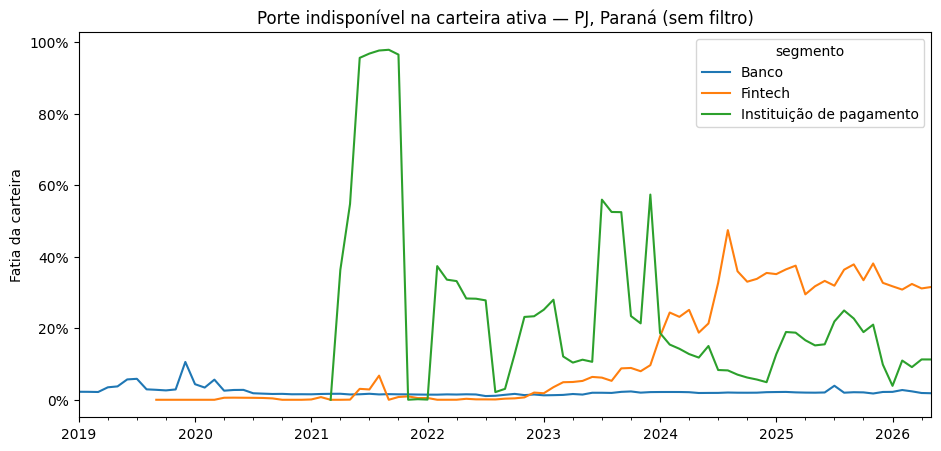

In [4]:
SEG = ['Banco', 'Fintech', 'Instituição de pagamento']
base = agg[agg.segmento.isin(SEG)]

total = base.groupby(['data_base', 'segmento'], observed=True)['carteira_ativa'].sum()
indisp = (base[base.porte_indisponivel]
          .groupby(['data_base', 'segmento'], observed=True)['carteira_ativa'].sum()
          .reindex(total.index, fill_value=0))

serie = (indisp / total).unstack('segmento')

ax = serie.plot()
ax.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
ax.set_title('Porte indisponível na carteira ativa — PJ, Paraná (sem filtro)')
ax.set_ylabel('Fatia da carteira'); ax.set_xlabel('')
plt.show()

### Leitura da seção 5

Três linhas, três comportamentos.

**Banco** — plano em torno de 2% por sete anos. Atravessa a pandemia e o ciclo
de juros sem se mover. Isso é mais valioso do que parece: é um **grupo de
controle que não foi construído**. Ele estava na base, e só apareceu porque
quebramos o número por segmento em vez de olhar o agregado.

**Fintech** — sai de perto de zero e sobe de forma sustentada. Tendência, não
oscilação.

**Instituição de pagamento** — vai a 97%, cai a zero, volta a 37%. Isso não é
comportamento econômico. Nenhum mercado se reorganiza assim de um mês para o
outro.

O trecho instável está no início da série, quando o segmento mal existia no
estado. É esse problema que as próximas duas seções resolvem.

## 6. Por que um piso de participação de mercado não serve

O reflexo natural diante da linha instável é cortar segmentos pequenos: "só
analiso quem tem pelo menos 1% do mercado".

**Esse critério não funciona aqui, e é importante entender por quê.**

Pela tabela da seção 3, a Fintech é *menor* que a Instituição de pagamento.
Qualquer piso por tamanho relativo que elimine a linha instável elimina também a
linha que sustenta a tese. O critério cortaria justamente o objeto do estudo.

Há um problema mais fundo: participação de mercado e estabilidade da proporção
não são a mesma coisa. Um segmento pequeno com muitos contratos pequenos produz
proporção estável. Um segmento maior com pouquíssimos contratos produz proporção
instável. O que queremos medir é a **estabilidade**, então o critério tem que
mirar nela diretamente.

## 7. O diagnóstico: quanto um único contrato desloca a proporção

A ideia: se um contrato só é capaz de mover a proporção em vários pontos
percentuais, aquela proporção não descreve o mercado — descreve o contrato.

Com $N$ operações no mês, uma operação de tamanho médio representa $1/N$ do
saldo. Em pontos percentuais, o deslocamento é $100/N$.

### O obstáculo: não sabemos $N$ exatamente

A documentação da versão 1 do SCR.data diz:

> Casos em que o número de operações seja inferior ou igual a 15, a informação
> divulgada será "<= 15".

Ou seja, células com poucas operações têm a contagem suprimida. Sabemos apenas
que estão entre **1 e 15**. E a supressão é mais frequente onde as células são
pequenas — isto é, exatamente nos segmentos que nos interessam.

**A consequência é séria e vale olhar antes de continuar.**

In [5]:
diag = base.groupby(['data_base', 'segmento'], observed=True).agg(
    ops_conhecidas=('operacoes', 'sum'),
    suprimidas=('celulas_suprimidas', 'sum'),
    celulas=('celulas', 'sum'))

diag['fatia_suprimida'] = diag['suprimidas'] / diag['celulas']

print('Fatia das células com contagem suprimida:')
print((diag['fatia_suprimida'].groupby('segmento')
       .agg(media='mean', mediana='median', maximo='max')).round(3))

Fatia das células com contagem suprimida:
                          media  mediana  maximo
segmento                                        
Banco                     0.254    0.253   0.271
Fintech                   0.707    0.689   1.000
Instituição de pagamento  0.355    0.325   0.870


**Sete em cada dez células da Fintech têm a contagem suprimida**, chegando a
100% em alguns meses. O denominador do diagnóstico é, no segmento que sustenta a
tese, o dado menos confiável da base.

Isso **não** contamina a série da seção 5 — ela é feita de `carteira_ativa`, que
não é suprimida. Contamina apenas o diagnóstico de estabilidade.

### A saída: não fingir precisão, e sim calcular a faixa

Em vez de escolher um valor para as células suprimidas, calculamos os dois
extremos que a regra permite:

- cada célula suprimida vale **1** → total mínimo → deslocamento **máximo**
- cada célula suprimida vale **15** → total máximo → deslocamento **mínimo**

O valor verdadeiro está entre os dois. Reportar a faixa é mais honesto do que
reportar um ponto que não temos como justificar.

Deslocamento de um contrato médio, em pontos percentuais (mediana):
                          pior_caso  melhor_caso
segmento                                        
Banco                        0.0001       0.0001
Fintech                      0.0307       0.0205
Instituição de pagamento     0.0019       0.0019


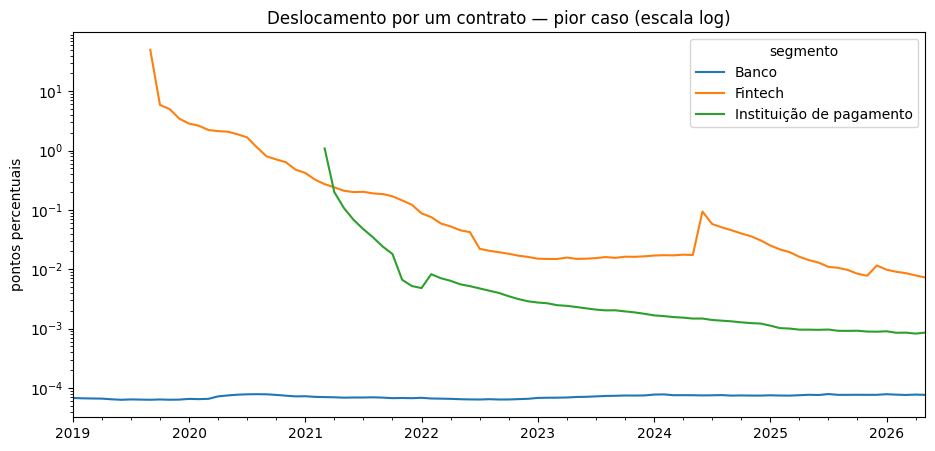

In [6]:
diag['ops_min'] = diag['ops_conhecidas'] + 1 * diag['suprimidas']
diag['ops_max'] = diag['ops_conhecidas'] + 15 * diag['suprimidas']

impacto_max = (100 / diag['ops_min']).unstack('segmento')   # pior caso
impacto_min = (100 / diag['ops_max']).unstack('segmento')   # melhor caso

print('Deslocamento de um contrato médio, em pontos percentuais (mediana):')
print(pd.DataFrame({'pior_caso': impacto_max.median(),
                    'melhor_caso': impacto_min.median()}).round(4))

ax = impacto_max.plot(logy=True)
ax.set_title('Deslocamento por um contrato — pior caso (escala log)')
ax.set_ylabel('pontos percentuais'); ax.set_xlabel('')
plt.show()

### Uma ressalva sobre a própria métrica

`100/N` é o deslocamento de um contrato **de tamanho médio**. Contratos reais
variam muito de tamanho, e valor é bem mais concentrado que contagem. Um
contrato grande desloca a proporção mais do que `100/N` sugere.

Então a métrica é um **piso** do deslocamento real, não uma medida dele. Ela
serve para ordenar meses do mais para o menos confiável, e não para afirmar
"este mês tem erro de X pontos".

Métrica imperfeita usada com o rótulo certo é trabalho honesto. A mesma métrica
apresentada como precisa seria o contrário.

## 8. A conclusão depende do parâmetro escolhido?

Esta é a seção mais importante do caderno.

Precisamos de um teto: acima de quanto de deslocamento um mês é considerado
não confiável e sai do gráfico? Qualquer número escolhido aqui é atacável —
"você escolheu o corte que fazia o gráfico funcionar".

**A resposta não é defender um número. É mostrar que a conclusão não depende
dele.** Recalculamos tudo sob vários tetos, incluindo o caso sem filtro nenhum.

In [7]:
def leitura(imp, teto):
    eleg = (imp.reindex(serie.index) <= teto).fillna(False)
    f = serie.where(eleg[serie.columns])['Fintech'].dropna()
    if len(f) < 3:
        return None
    x = (f.index - f.index[0]).days / 365.25
    return {'meses_fintech': len(f), 'inicio': f.index[0].strftime('%Y-%m'),
            'primeiro_%': round(f.iloc[0] * 100, 1),
            'ultimo_%': round(f.iloc[-1] * 100, 1),
            'inclinacao_pp_ano': round(np.polyfit(x, f.values, 1)[0] * 100, 2)}

linhas = {f'teto {t}': leitura(impacto_max, t) for t in [0.05, 0.10, 0.25, 0.50, 1.00]}
linhas['sem filtro'] = leitura(impacto_max, 1e9)
pd.DataFrame(linhas).T

,meses_fintech,inicio,primeiro_%,ultimo_%,inclinacao_pp_ano
teto 0.05,46,2022-05,0.3,31.5,10.98
teto 0.1,53,2022-01,0.5,31.5,10.69
teto 0.25,62,2021-04,0.0,31.5,9.15
teto 0.5,66,2020-12,0.0,31.5,8.59
teto 1.0,69,2020-09,0.4,31.5,8.18
sem filtro,81,2019-09,0.0,31.5,6.68


### Leitura da seção 8 — o resultado que sustenta o projeto

A Fintech parte de praticamente zero e chega a **31,5% sob todos os tetos,
inclusive sem filtro nenhum**. A inclinação fica entre 6,7 e 11,0 pontos
percentuais por ano, sempre fortemente positiva.

**O teto decide quanto da série é mostrado. Não decide o que ela diz.**

Isso encerra duas objeções de uma vez:

1. "Você escolheu o corte que dava certo" — não há corte que faça o achado
   desaparecer.
2. "Seu diagnóstico depende de um denominador ruim" — verdade, mas como a
   conclusão sobrevive até sem o diagnóstico, a fragilidade dele deixa de ser
   fatal.

Esta tabela vale mais no repositório do que qualquer defesa do valor escolhido.

## 9. Auditoria: o que foi descartado, e por qual motivo

Meses somem do gráfico por duas razões diferentes, e um leitor atento vai querer
saber qual foi qual. Mês instável e mês sem diagnóstico não são a mesma coisa —
o primeiro é decisão metodológica, o segundo é limitação do dado.

Silêncio num gráfico é o que um revisor procura primeiro.

In [8]:
TETO_PP = 0.10  # escolhido na seção 8; ver DECISOES.md

imp = impacto_max.reindex(serie.index)
auditoria = pd.DataFrame({
    'meses_na_serie': serie.notna().sum(),
    'sem_diagnostico': imp.isna().sum(),
    'reprovados_instabilidade': (imp > TETO_PP).fillna(False).sum(),
    'mantidos': (imp <= TETO_PP).fillna(False).sum(),
})
print(auditoria)

eleg = (imp <= TETO_PP).fillna(False)
serie_filtrada = serie.where(eleg[serie.columns])

                          meses_na_serie  sem_diagnostico  reprovados_instabilidade  mantidos
segmento                                                                                     
Banco                                 89                0                         0        89
Fintech                               81                8                        28        53
Instituição de pagamento              63               26                         3        60


## 10. As duas ressalvas que continuam abertas

Nenhuma delas derruba o achado. Ambas precisam estar escritas no README.

### 10.1 O recorte é o Paraná, não o Brasil

A Fintech é cerca de 0,06% do crédito PJ do estado. Fatia grande de um todo
pequeno. A expansão nacional, usando `uf` como chave de agregação, é o próximo
passo e é pré-requisito para publicar qualquer número como fato de mercado.

### 10.2 Um movimento não explicado em julho de 2025

Havia a suspeita de que a subida da Fintech fosse artefato da migração da
versão 1 para a versão 2 do SCR.data. Duas verificações foram feitas.

**A documentação:** as metodologias V1 e V2 não trazem a data da transição. Mas
mostram que o campo `segmento` e a definição de `carteira_ativa` **só existem na
V2**. Como os arquivos usados aqui trazem os dois campos em toda a série desde
2019, os dados foram republicados retroativamente em formato V2 — não há emenda
de formato no meio da série.

**O log de ingestão:** os meses suspeitos (jun/2024 e jul/2025) mostram queda de
2,2% e 4,6% no total de linhas lidas, mas apenas 1,5% e 0,7% nas linhas do
recorte. Oscilação, não quebra estrutural.

O teste abaixo compara os três meses antes e depois de cada data suspeita.

In [9]:
for corte in ['2024-06-01', '2025-07-01']:
    d = pd.Timestamp(corte)
    antes = serie_filtrada.loc[d - pd.DateOffset(months=3):d - pd.DateOffset(days=1)].mean() * 100
    depois = serie_filtrada.loc[d:d + pd.DateOffset(months=2)].mean() * 100
    tab = (pd.DataFrame({'antes_%': antes, 'depois_%': depois})
             .assign(delta_pp=lambda t: t['depois_%'] - t['antes_%']).round(2))
    print(f'--- {corte} ---'); print(tab); print()

--- 2024-06-01 ---
                          antes_%  depois_%  delta_pp
segmento                                             
Banco                        2.06      1.92     -0.14
Fintech                     22.35     27.00      4.65
Instituição de pagamento    12.94     11.67     -1.27

--- 2025-07-01 ---
                          antes_%  depois_%  delta_pp
segmento                                             
Banco                        2.01      2.95      0.94
Fintech                     31.47     34.12      2.65
Instituição de pagamento    15.78     23.42      7.64



**Como ler este teste.** Uma mudança na forma de coletar o campo atingiria
todas as instituições. Se apenas a Fintech se move, a mudança de coleta não
explica o fenômeno.

**Junho de 2024 comporta-se assim:** o Banco praticamente não se move e a
Fintech sobe.

**Julho de 2025 não.** O Banco sobe quase 1 ponto percentual, saindo de uma
linha que ficou plana por sete anos, e a Instituição de pagamento sobe bem mais.

Não há evidência de que isso seja a mudança de versão — pode ser composição,
sazonalidade, coincidência. Mas também não está descartado, e o argumento do
"banco imóvel" não se aplica a esse mês específico.

**A postura correta é declarar.** O trecho da série anterior a julho de 2025 já
vai de cerca de 0,5% a mais de 30%: o achado se sustenta mesmo que o final da
série receba asterisco.

## 11. Gráfico final

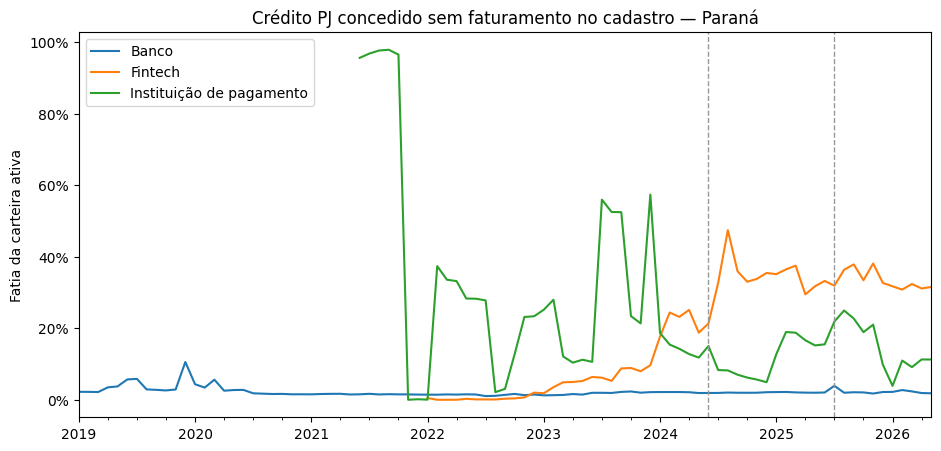

In [10]:
ax = serie_filtrada.plot()
for corte in ['2024-06-01', '2025-07-01']:
    ax.axvline(pd.Timestamp(corte), color='0.6', linestyle='--', linewidth=1)
ax.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
ax.set_title('Crédito PJ concedido sem faturamento no cadastro — Paraná')
ax.set_ylabel('Fatia da carteira ativa'); ax.set_xlabel('')
ax.legend(title='')
plt.show()

## 12. Onde isto chegou, e o que vem depois

**Estabelecido:**

- A hipótese original — banco que não enquadra pequenas empresas — foi testada
  e refutada. O Banco fica em 1,8%.
- Existe crédito PJ concedido sem faturamento no cadastro, e ele se concentra em
  Fintech e Instituição de pagamento.
- Na Fintech, essa fatia sai de perto de zero e chega a 31,5%, sob qualquer teto
  de estabilidade e também sem filtro.
- A linha plana do Banco funciona como controle em toda a série, com a exceção
  discutida na seção 10.2.

**Não estabelecido, e que não deve ser afirmado:**

- *Por que* o campo está vazio. A base registra ausência, não motivo. A
  explicação por subscrição via fluxo transacional é hipótese, não resultado.
- Que o padrão do Paraná valha para o Brasil. Falta a agregação nacional.
- Que o movimento de julho de 2025 seja comportamento de mercado.

**Próximos passos, em ordem:**

1. Agregação nacional com `uf` como chave.
2. Investigar julho de 2025 com dado nacional — se o salto do Banco não se
   repetir fora do Paraná, era composição local.
3. Publicar o repositório com README em inglês e o CSV agregado.
4. Hipótese seguinte: a inadimplência difere entre crédito com porte informado e
   com porte indisponível, dentro do mesmo segmento e mês? Se diferir, o campo
   vazio deixa de ser medida de método e passa a ser sinal de risco.